In [1]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

In [2]:
# Step 1: File Paths
BASE_DIR = Path("/home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction")
TRAIN_PATH = BASE_DIR / "data" / "raw" / "train.csv"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("--- STEP 1: Loading Dataset ---")
df = pd.read_csv(TRAIN_PATH)

--- STEP 1: Loading Dataset ---


In [3]:
# ------------------------------------------------------------------------------
# 1. Dataset Overview
# ------------------------------------------------------------------------------
print("\n--- STEP 2: General Dataset Overview ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types and Non-Null Counts:")
print(df.info())


--- STEP 2: General Dataset Overview ---
Dataset Dimensions: 58592 rows, 44 columns

First 5 Rows:
  policy_id  policy_tenure  age_of_car  age_of_policyholder area_cluster  \
0   ID00001       0.515874        0.05             0.644231           C1   
1   ID00002       0.672619        0.02             0.375000           C2   
2   ID00003       0.841110        0.02             0.384615           C3   
3   ID00004       0.900277        0.11             0.432692           C4   
4   ID00005       0.596403        0.11             0.634615           C5   

   population_density  make segment model fuel_type  ... is_brake_assist  \
0                4990     1       A    M1       CNG  ...              No   
1               27003     1       A    M1       CNG  ...              No   
2                4076     1       A    M1       CNG  ...              No   
3               21622     1      C1    M2    Petrol  ...             Yes   
4               34738     2       A    M3    Petrol  ...       

In [4]:
# ------------------------------------------------------------------------------
# 2. Missing Values Analysis
# ------------------------------------------------------------------------------
print("\n--- STEP 3: Checking Missing Values ---")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame(
    {"Missing Count": missing_values, "Percentage (%)": missing_percent}
)
print(missing_df[missing_df["Missing Count"] > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset!")


--- STEP 3: Checking Missing Values ---
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []
No missing values found in the dataset!


In [5]:
# ------------------------------------------------------------------------------
# 3. Target Variable Analysis (Class Imbalance)
# ------------------------------------------------------------------------------
print("\n--- STEP 4: Target Variable Analysis ('is_claim') ---")
claim_counts = df["is_claim"].value_counts()
claim_percent = df["is_claim"].value_counts(normalize=True) * 100

print("Claim Distribution (Counts):")
print(claim_counts)
print("\nClaim Distribution (Percentage):")
print(claim_percent.round(2))

# Plot Target Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="is_claim", data=df, palette="Set2")
plt.title("Target Distribution: Insurance Claim (is_claim)", fontsize=12)
plt.xlabel("Is Claim (0 = No, 1 = Yes)")
plt.ylabel("Count")

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height} ({height / len(df) * 100:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png")
print(f"Saved plot: {REPORTS_DIR / 'target_distribution.png'}")
plt.close()


--- STEP 4: Target Variable Analysis ('is_claim') ---
Claim Distribution (Counts):
is_claim
0    54844
1     3748
Name: count, dtype: int64

Claim Distribution (Percentage):
is_claim
0    93.6
1     6.4
Name: proportion, dtype: float64


/tmp/ipykernel_41054/324559602.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="is_claim", data=df, palette="Set2")


Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/target_distribution.png



--- STEP 5: Numerical Features Summary ---
                       count          mean           std          min  \
policy_tenure        58592.0      0.611246      0.414156     0.002735   
age_of_car           58592.0      0.069424      0.056721     0.000000   
age_of_policyholder  58592.0      0.469420      0.122886     0.288462   
population_density   58592.0  18826.858667  17660.174792   290.000000   
make                 58592.0      1.763722      1.136988     1.000000   
airbags              58592.0      3.137066      1.832641     1.000000   
displacement         58592.0   1162.355851    266.304786   796.000000   
cylinder             58592.0      3.626963      0.483616     3.000000   
gear_box             58592.0      5.245443      0.430353     5.000000   
turning_radius       58592.0      4.852893      0.228061     4.500000   
length               58592.0   3850.476891    311.457119  3445.000000   
width                58592.0   1672.233667    112.089135  1475.000000   
height 

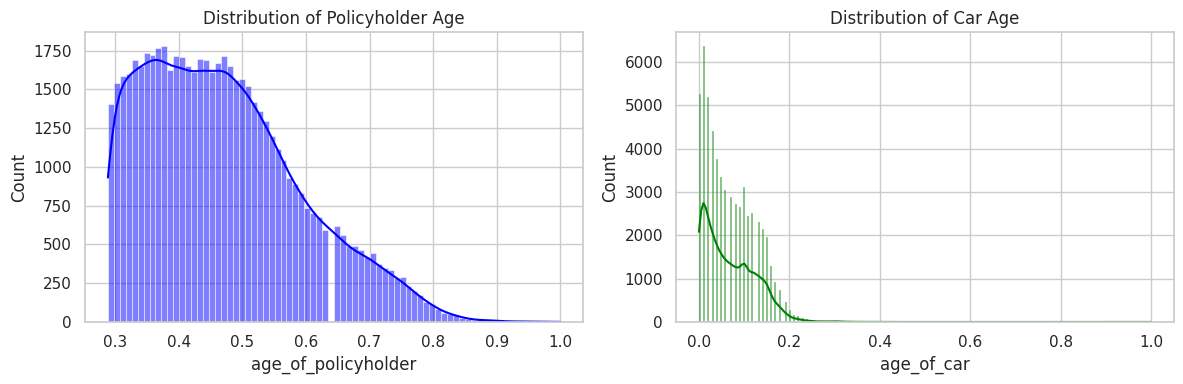

In [6]:
# ------------------------------------------------------------------------------
# 4. Numerical Features Summary
# ------------------------------------------------------------------------------
print("\n--- STEP 5: Numerical Features Summary ---")
print(df.describe().T)

# Plot distribution of Age features
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df["age_of_policyholder"], kde=True, color="blue")
plt.title("Distribution of Policyholder Age")

plt.subplot(1, 2, 2)
sns.histplot(df["age_of_car"], kde=True, color="green")
plt.title("Distribution of Car Age")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "age_distributions.png")
print(f"Saved plot: {REPORTS_DIR / 'age_distributions.png'}")
plt.show()


--- STEP 6: Key Categorical Features vs Target ---
Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/categorical_vs_target.png


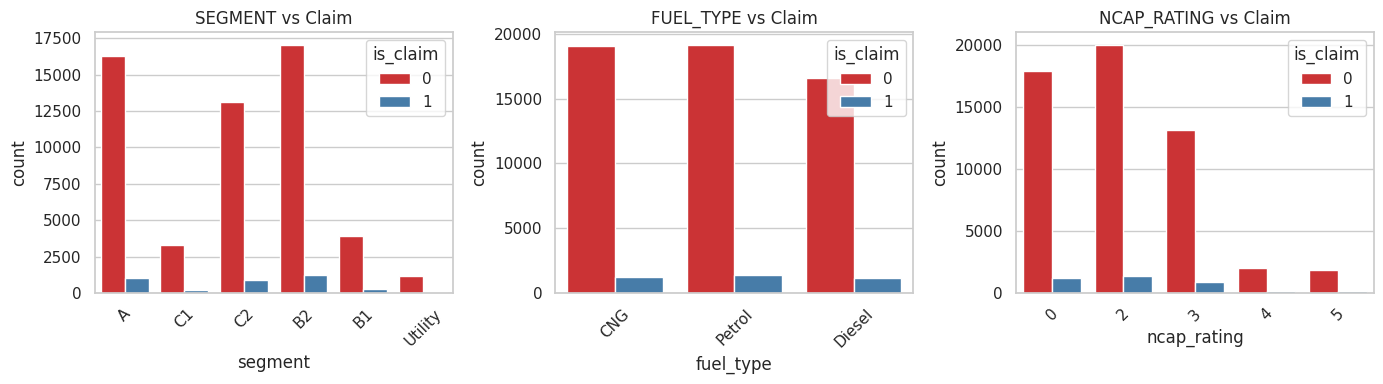

In [8]:
# ------------------------------------------------------------------------------
# 5. Categorical Features Analysis
# ------------------------------------------------------------------------------
print("\n--- STEP 6: Key Categorical Features vs Target ---")
categorical_cols = ["segment", "fuel_type", "ncap_rating"]

plt.figure(figsize=(14, 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue="is_claim", data=df, palette="Set1")
    plt.title(f"{col.upper()} vs Claim")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "categorical_vs_target.png")
print(f"Saved plot: {REPORTS_DIR / 'categorical_vs_target.png'}")
plt.show()


--- STEP 7: Correlation Matrix ---
Saved plot: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports/correlation_heatmap.png


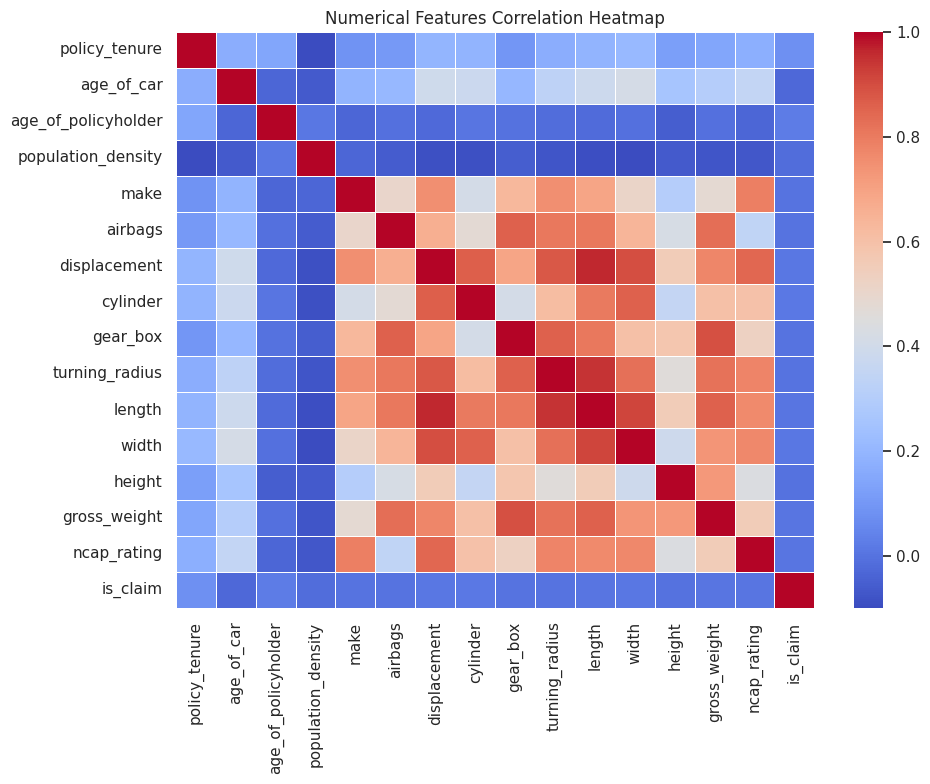


SUCCESS: EDA COMPLETED & REPORTS SAVED
All generated plots are saved in: /home/dell/Documents/Final_project_Car_Insurance_Claim_Prediction/reports


In [10]:
# ------------------------------------------------------------------------------
# 6. Correlation Analysis for Numeric Columns
# ------------------------------------------------------------------------------
print("\n--- STEP 7: Correlation Matrix ---")
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Numerical Features Correlation Heatmap")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlation_heatmap.png")
print(f"Saved plot: {REPORTS_DIR / 'correlation_heatmap.png'}")
plt.show()

print("\n==================================================")
print("SUCCESS: EDA COMPLETED & REPORTS SAVED")
print(f"All generated plots are saved in: {REPORTS_DIR}")
print("==================================================")